<a href="https://colab.research.google.com/github/TheAIRhishi/AGI_AI_B.S.2083/blob/main/small_Time_seriesGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, TensorDataset


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print("Using device:", device)

Using device: cuda


In [3]:
from google.colab import files
uploaded = files.upload()

Saving jena_climate_2009_2016.csv to jena_climate_2009_2016.csv


In [4]:
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)

print("Shape of full dataset:", df.shape)
display(df.head())

Shape of full dataset: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [7]:
print(df.columns.tolist())

['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


In [8]:
#Selecting weather relevant features


feature_cols = [
    'p (mbar)',
    'T (degC)',
    'Tpot (K)',
    'Tdew (degC)',
    'rh (%)',
    'VPmax (mbar)',
    'VPact (mbar)',
    'VPdef (mbar)',
    'sh (g/kg)',
    'H2OC (mmol/mol)',
    'rho (g/m**3)',
    'wv (m/s)',
    'max. wv (m/s)',
    'wd (deg)'
]

data_df = df[feature_cols].copy()
print("Selected feature shape:", data_df.shape)
data_df.head()

Selected feature shape: (420551, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [9]:
# Checking for missing values
print(data_df.isnull().sum())

p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64


In [10]:
#Downsampling from 10 mins to 1 hour
sampling_step = 6   # one point every 6 rows = hourly sampling
data_df = data_df.iloc[::sampling_step].reset_index(drop=True)

print("Shape after downsampling:", data_df.shape)
data_df.head()



Shape after downsampling: (70092, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
2,996.63,-8.85,264.57,-9.70,93.5,3.12,2.92,0.20,1.82,2.93,1312.11,0.16,0.50,158.3
3,996.87,-8.84,264.56,-9.69,93.5,3.13,2.92,0.20,1.83,2.93,1312.37,0.07,0.25,129.3
4,997.05,-9.23,264.15,-10.25,92.2,3.03,2.79,0.24,1.74,2.80,1314.62,0.10,0.38,203.9


In [11]:
print(df.shape)
print(df.columns.tolist())

(420551, 15)
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


In [12]:

seq_len = 40
features = 14
n_embd = 512
n_head = 8
n_layer = 4
batch_size = 64
epochs = 8

print("seq_len:", seq_len)
print("n_embd:", n_embd)
print("n_head:", n_head)
print("n_layer:", n_layer)
print("batch_size:", batch_size)
print("epochs:", epochs)
print("features:", features)



seq_len: 40
n_embd: 512
n_head: 8
n_layer: 4
batch_size: 64
epochs: 8
features: 14


In [13]:
data = data_df.values.astype(np.float32)

T = len(data)

print(data.shape)

(70092, 14)


In [14]:
# =========================================
# SMALL DATA EXPERIMENT
# =========================================

small_size = 10000   # try 10k points instead of full 70k

data_small = data[:small_size]

T_small = len(data_small)

print("Small data shape:", data_small.shape)

Small data shape: (10000, 14)


In [15]:
split_idx_small = int(0.7 * T_small)

train_small = data_small[:split_idx_small]
test_small = data_small[split_idx_small:]

print(train_small.shape)
print(test_small.shape)

(7000, 14)
(3000, 14)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler_small = StandardScaler()

train_small = scaler_small.fit_transform(train_small)
test_small = scaler_small.transform(test_small)

In [20]:
def make_windows(arr, seq_len):

    X=[]
    Y=[]

    for i in range(len(arr)-seq_len):

        X.append(arr[i:i+seq_len])
        Y.append(arr[i+1:i+seq_len+1])

    return np.array(X), np.array(Y)

In [21]:
train_x_s, train_y_s = make_windows(train_small, seq_len)
test_x_s, test_y_s = make_windows(test_small, seq_len)

print(train_x_s.shape)
print(test_x_s.shape)

(6960, 40, 14)
(2960, 40, 14)


In [30]:
train_x_s = torch.tensor(train_x_s, dtype=torch.float32)
train_y_s = torch.tensor(train_y_s, dtype=torch.float32)

test_x_s = torch.tensor(test_x_s, dtype=torch.float32)
test_y_s = torch.tensor(test_y_s, dtype=torch.float32)

train_loader_s = DataLoader(
    TensorDataset(train_x_s, train_y_s),
    batch_size=batch_size,
    shuffle=True
)

/tmp/ipykernel_1807/799581249.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_x_s = torch.tensor(train_x_s, dtype=torch.float32)
/tmp/ipykernel_1807/799581249.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y_s = torch.tensor(train_y_s, dtype=torch.float32)
/tmp/ipykernel_1807/799581249.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_x_s = torch.tensor(test_x_s, dtype=torch.float32)
/tmp/ipykernel_1807/799581249.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().

In [23]:


class Head(nn.Module):

    def __init__(self, head_size):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(seq_len, seq_len))
        )

    def forward(self, x):

        B, T, E = x.shape

        k = self.key(x)
        q = self.query(x)

        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)

        wei = wei.masked_fill(
            self.tril[:T, :T] == 0,
            float('-inf')
        )

        wei = F.softmax(wei, dim=-1)

        v = self.value(x)

        return wei @ v

In [24]:
#Multi Head

class MultiHead(nn.Module):

    def __init__(self):
        super().__init__()

        head_size = n_embd // n_head

        self.heads = nn.ModuleList(
            [Head(head_size) for _ in range(n_head)]
        )

        self.proj = nn.Linear(n_embd, n_embd)

    def forward(self, x):

        x = torch.cat([h(x) for h in self.heads], dim=-1)

        return self.proj(x)

In [25]:
#Feedforward


class FeedForward(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd)
        )

    def forward(self, x):
        return self.net(x)


In [26]:
#Block

class Block(nn.Module):

    def __init__(self):
        super().__init__()

        self.sa = MultiHead()
        self.ff = FeedForward()

        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):

        x = x + self.sa(self.ln1(x))
        x = x + self.ff(self.ln2(x))

        return x

In [27]:
# TIME SERIES GPT

class TimeSeriesGPT(nn.Module):

    def __init__(self):
        super().__init__()

        self.feature_proj = nn.Linear(features, n_embd)

        self.pos_emb = nn.Embedding(seq_len, n_embd)

        self.blocks = nn.Sequential(
            *[Block() for _ in range(n_layer)]
        )

        self.ln = nn.LayerNorm(n_embd)

        self.head = nn.Linear(n_embd, features)

    def forward(self, x):

        B, T, F = x.shape

        x = self.feature_proj(x)

        pos = torch.arange(T, device=x.device)

        x = x + self.pos_emb(pos)

        x = self.blocks(x)

        x = self.ln(x)

        return self.head(x)

In [28]:
#Model Creation

model_small = TimeSeriesGPT().to(device)
optimizer_small = torch.optim.Adam(model_small.parameters(), lr=3e-4)

In [35]:

# TRAINING LOOP (SMALL DATA)

for epoch in range(epochs):

    model_small.train()

    total_loss = 0

    for xb, yb in train_loader_s:

        xb = xb.to(device)
        yb = yb.to(device)

        pred = model_small(xb)

        loss = F.mse_loss(pred, yb)

        optimizer_small.zero_grad()
        loss.backward()
        optimizer_small.step()

        total_loss += loss.item()

    print("epoch", epoch, "loss", total_loss / len(train_loader_s))

epoch 0 loss 0.15180235533812725
epoch 1 loss 0.10707399392620139
epoch 2 loss 0.10355038858881783
epoch 3 loss 0.10181575500910435
epoch 4 loss 0.0997333437067653
epoch 5 loss 0.09721075989511035
epoch 6 loss 0.09433418136397632
epoch 7 loss 0.09070604137324412


In [36]:
# TEST EVALUATION

model_small.eval()

with torch.no_grad():
    xb = test_x_s.to(device)
    pred_s = model_small(xb).cpu().numpy()
    true_s = test_y_s.numpy()

mse_s = np.mean((pred_s - true_s) ** 2)

r2_s = r2_score(
    true_s.reshape(-1, features),
    pred_s.reshape(-1, features)
)

print("Small Data MSE:", mse_s)
print("Small Data R2 :", r2_s)

Small Data MSE: 0.100855485
Small Data R2 : 0.8943890929222107


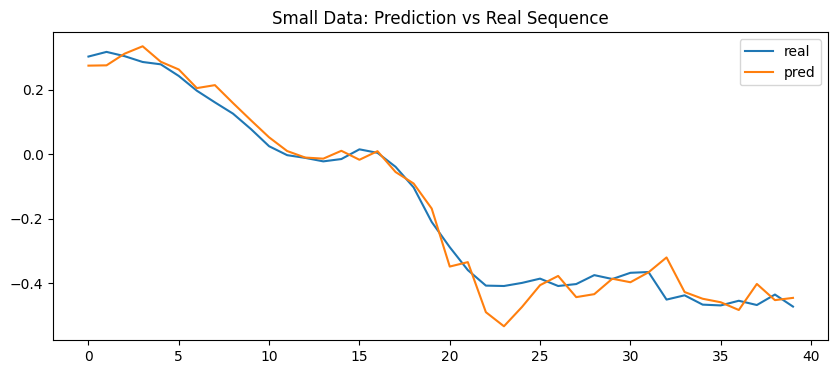

In [40]:

feature_id = 0

plt.figure(figsize=(10,4))

plt.plot(true_s[0, :, feature_id], label="real")

plt.plot(pred_s[0, :, feature_id], label="pred")

plt.legend()

plt.title("Small Data: Prediction vs Real Sequence")

plt.show()

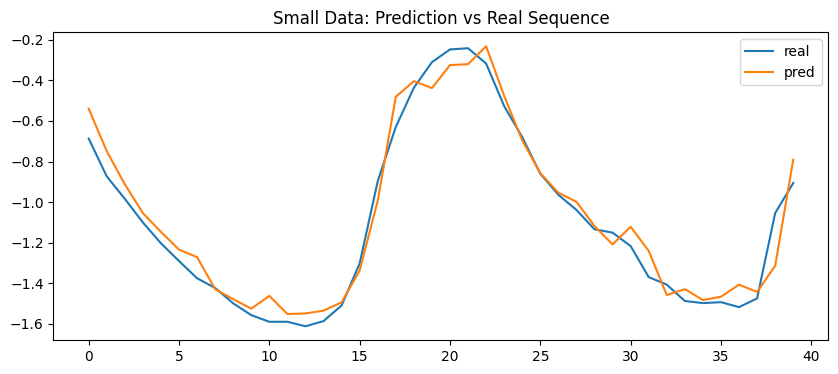

In [42]:

# PLOT PREDICTED VS REAL (SMALL DATA)
feature_id = 1 # T Dec

plt.figure(figsize=(10,4))

plt.plot(true_s[1, :, feature_id], label="real")

plt.plot(pred_s[1, :, feature_id], label="pred")

plt.legend()

plt.title("Small Data: Prediction vs Real Sequence")

plt.show()